# 04 — Test del Retriever RAG

Evalúa la calidad de recuperación del índice FAISS con **10 consultas de prueba** que cubren
los cinco pilares temáticos del corpus.

Métricas calculadas:
- **precision@3** (semántico): fracción de los top-3 chunks semánticos cuyo pilar coincide con el esperado.
- **hit@any**: si algún resultado (semántico *o* forzado) pertenece al pilar esperado.
- **Global p@3**: media aritmética de precision@3 sobre las 10 consultas.

In [1]:
import os
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
os.chdir(str(PROJECT_ROOT))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid")

print(f"Working dir : {Path.cwd()}")
print(f"Project root: {PROJECT_ROOT}")

Working dir : /home/adrian/projects/chatbots/chatbot-ciberacoso
Project root: /home/adrian/projects/chatbots/chatbot-ciberacoso


In [2]:
TEST_CASES = [
    {
        "label": "Q1",
        "query": "tengo miedo de ir al instituto porque me amenazan por internet",
        "emotion": "fear",
        "expected_pillars": {1, 2},
        "description": "Miedo + amenazas → psicoeducación + TCC",
    },
    {
        "label": "Q2",
        "query": "me han publicado fotos mías sin permiso y no sé qué hacer",
        "emotion": "fear",
        "expected_pillars": {1, 5},
        "description": "Sexting/sextorsión → protocolo + autodefensa digital",
    },
    {
        "label": "Q3",
        "query": "no puedo parar de llorar me siento muy mal y no sé por qué",
        "emotion": "sadness",
        "expected_pillars": {2},
        "description": "Tristeza intensa → técnicas TCC",
    },
    {
        "label": "Q4",
        "query": "todo el mundo me odia en clase y en los grupos de whatsapp me ignoran",
        "emotion": "sadness",
        "expected_pillars": {2},
        "description": "Distorsión cognitiva todo/nada → TCC",
    },
    {
        "label": "Q5",
        "query": "quiero denunciar al que me acosa pero no sé cómo hacerlo",
        "emotion": "anger",
        "expected_pillars": {1},
        "description": "Denuncia → protocolo P1",
    },
    {
        "label": "Q6",
        "query": "cómo bloqueo a alguien en instagram que me está insultando",
        "emotion": "others",
        "expected_pillars": {5},
        "description": "Autodefensa digital Instagram → P5",
    },
    {
        "label": "Q7",
        "query": "todo lo que hago sale mal y no sirvo para nada",
        "emotion": "sadness",
        "expected_pillars": {3},
        "description": "Baja autoestima → hope-focused / contranarrativa",
    },
    {
        "label": "Q8",
        "query": "me van a pegar si no hago lo que dicen me da muchísimo miedo",
        "emotion": "fear",
        "expected_pillars": {4},
        "description": "Amenaza física urgente → PAP crisis",
    },
    {
        "label": "Q9",
        "query": "ya no quiero seguir viviendo nadie me va a echar de menos",
        "emotion": "sadness",
        "expected_pillars": {4},
        "description": "Ideación suicida → PAP crisis",
    },
    {
        "label": "Q10",
        "query": "me da mucha vergüenza lo que pasó y no puedo contárselo a nadie",
        "emotion": "disgust",
        "expected_pillars": {2},
        "description": "Vergüenza → normalización TCC",
    },
]

print(f"{len(TEST_CASES)} consultas de prueba cargadas.")

10 consultas de prueba cargadas.


In [3]:
from src.rag import RAGRetriever

retriever = RAGRetriever()

print("RAGRetriever listo.")
print(f"  Vectorstore   : {retriever.vectorstore_dir}")
print(f"  Chunks totales: {retriever.index.ntotal}")
print(f"  always_include: {len(retriever._always_include_indices)} chunk(s)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAGRetriever listo.
  Vectorstore   : data/vectorstore/faiss_index_v1
  Chunks totales: 40
  always_include: 1 chunk(s)


## Resultados por consulta

Para cada consulta se muestran:
- Los **top-3 chunks semánticos** con su pilar, score y si coincide con el esperado (`✓` / `·`).
- Los **chunks forzados** (always_include) añadidos por la regla de emoción.

In [4]:
PILLAR_NAMES = {
    1: "Protocolos",
    2: "TCC",
    3: "Esperanza",
    4: "PAP",
    5: "Autodefensa",
}

all_results = []

for tc in TEST_CASES:
    results = retriever.retrieve(query=tc["query"], emotion=tc["emotion"], top_k=3)

    semantic = [r for r in results if not r.forced]
    forced   = [r for r in results if r.forced]

    hits   = sum(1 for r in semantic if r.chunk.pillar in tc["expected_pillars"])
    p_at_3 = hits / 3
    hit_any = any(r.chunk.pillar in tc["expected_pillars"] for r in results)

    all_results.append(
        dict(tc=tc, results=results, semantic=semantic, forced=forced,
             p_at_3=p_at_3, hits=hits, hit_any=hit_any)
    )

    exp_str = ", ".join(f"P{p}" for p in sorted(tc["expected_pillars"]))
    status  = "\033[92m✓\033[0m" if hit_any else "\033[91m✗\033[0m"
    print(f"{'─'*62}")
    print(f"{tc['label']}  [{tc['emotion']:<7}]  precision@3={p_at_3:.2f}  {status}")
    print(f"  Query    : {tc['query']}")
    print(f"  Esperado : {exp_str}  — {tc['description']}")
    print(f"  Semántico:")
    for i, r in enumerate(semantic, 1):
        m = "✓" if r.chunk.pillar in tc["expected_pillars"] else "·"
        pname = PILLAR_NAMES[r.chunk.pillar]
        print(f"    {i}. [{r.chunk.id}] P{r.chunk.pillar}-{pname:<11} "
              f"score={r.score:.4f}  {m}  {r.chunk.title[:48]}")
    if forced:
        print(f"  Forzados :")
        for r in forced:
            pname = PILLAR_NAMES[r.chunk.pillar]
            print(f"    → [{r.chunk.id}] P{r.chunk.pillar}-{pname}  (always_include)")

print(f"{'─'*62}")

──────────────────────────────────────────────────────────────
Q1  [fear   ]  precision@3=0.33  ✓
  Query    : tengo miedo de ir al instituto porque me amenazan por internet
  Esperado : P1, P2  — Miedo + amenazas → psicoeducación + TCC
  Semántico:
    1. [P4_008] P4-PAP         score=0.5904  ·  Amenaza física directa — qué hacer si te amenaza
    2. [P1_003] P1-Protocolos  score=0.5252  ✓  Por qué el ciberacoso duele diferente al acoso p
    3. [P3_006] P3-Esperanza   score=0.4634  ·  Contranarrativa ante ataques por género o misogi
  Forzados :
    → [P4_007] P4-PAP  (always_include)
──────────────────────────────────────────────────────────────
Q2  [fear   ]  precision@3=0.67  ✓
  Query    : me han publicado fotos mías sin permiso y no sé qué hacer
  Esperado : P1, P5  — Sexting/sextorsión → protocolo + autodefensa digital
  Semántico:
    1. [P5_006] P5-Autodefensa score=0.5756  ✓  Recursos digitales y líneas de ayuda para seguri
    2. [P5_001] P5-Autodefensa score=0.4531  ✓  Cóm

## Tabla resumen

Verde ≥ 0.67 · Amarillo ≥ 0.34 · Rojo < 0.34

In [5]:
summary_rows = []
for res in all_results:
    tc = res["tc"]
    exp_str      = ", ".join(f"P{p}" for p in sorted(tc["expected_pillars"]))
    sem_pillars  = [r.chunk.pillar for r in res["semantic"]]
    forced_ids   = [r.chunk.id for r in res["forced"]]
    summary_rows.append(
        {
            "Consulta":      tc["label"],
            "Emoción":       tc["emotion"],
            "Esperado":      exp_str,
            "Top-3 pilares": str(sem_pillars),
            "Forzados":      ", ".join(forced_ids) if forced_ids else "—",
            "precision@3":   res["p_at_3"],
            "hit@any":       "✓" if res["hit_any"] else "✗",
        }
    )

df_summary   = pd.DataFrame(summary_rows)
global_p3    = df_summary["precision@3"].mean()
hit_any_rate = (df_summary["hit@any"] == "✓").mean()

print(f"Global precision@3 = {global_p3:.4f}  ({global_p3*100:.1f}%)")
print(f"hit@any rate       = {hit_any_rate:.4f}  ({hit_any_rate*100:.1f}%)")
print()


def _color_p3(val: float) -> str:
    if val >= 0.67:
        return "background-color: #d4edda; color: #155724"
    if val >= 0.34:
        return "background-color: #fff3cd; color: #856404"
    return "background-color: #f8d7da; color: #721c24"


# pandas >= 2.1 usa .map(); < 2.1 usa .applymap()
_styler_map = getattr(df_summary.style, "map", None) or df_summary.style.applymap

styled = (
    df_summary.style
    .pipe(lambda s: s.map(_color_p3, subset=["precision@3"])
          if hasattr(s, "map") else s.applymap(_color_p3, subset=["precision@3"]))
    .format({"precision@3": "{:.2f}"})
    .set_caption(
        f"Resumen RAG · Global precision@3 = {global_p3:.3f} · hit@any = {hit_any_rate:.2f}"
    )
    .hide(axis="index")
)
display(styled)

Global precision@3 = 0.4667  (46.7%)
hit@any rate       = 0.9000  (90.0%)



Consulta,Emoción,Esperado,Top-3 pilares,Forzados,precision@3,hit@any
Q1,fear,"P1, P2","[4, 1, 3]",P4_007,0.33,✓
Q2,fear,"P1, P5","[5, 5, 2]",P4_007,0.67,✓
Q3,sadness,P2,"[4, 4, 2]",P4_007,0.33,✓
Q4,sadness,P2,"[3, 5, 5]",P4_007,0.00,✗
Q5,anger,P1,"[1, 4, 5]",—,0.33,✓
Q6,others,P5,"[5, 5, 5]",—,1.00,✓
Q7,sadness,P3,"[2, 3, 2]",P4_007,0.33,✓
Q8,fear,P4,"[4, 3, 2]",P4_007,0.33,✓
Q9,sadness,P4,"[4, 4, 2]",P4_007,0.67,✓
Q10,disgust,P2,"[2, 2, 4]",—,0.67,✓


## Visualización

Figura guardada en: /home/adrian/projects/chatbots/chatbot-ciberacoso/eval/rag_test_precision.png


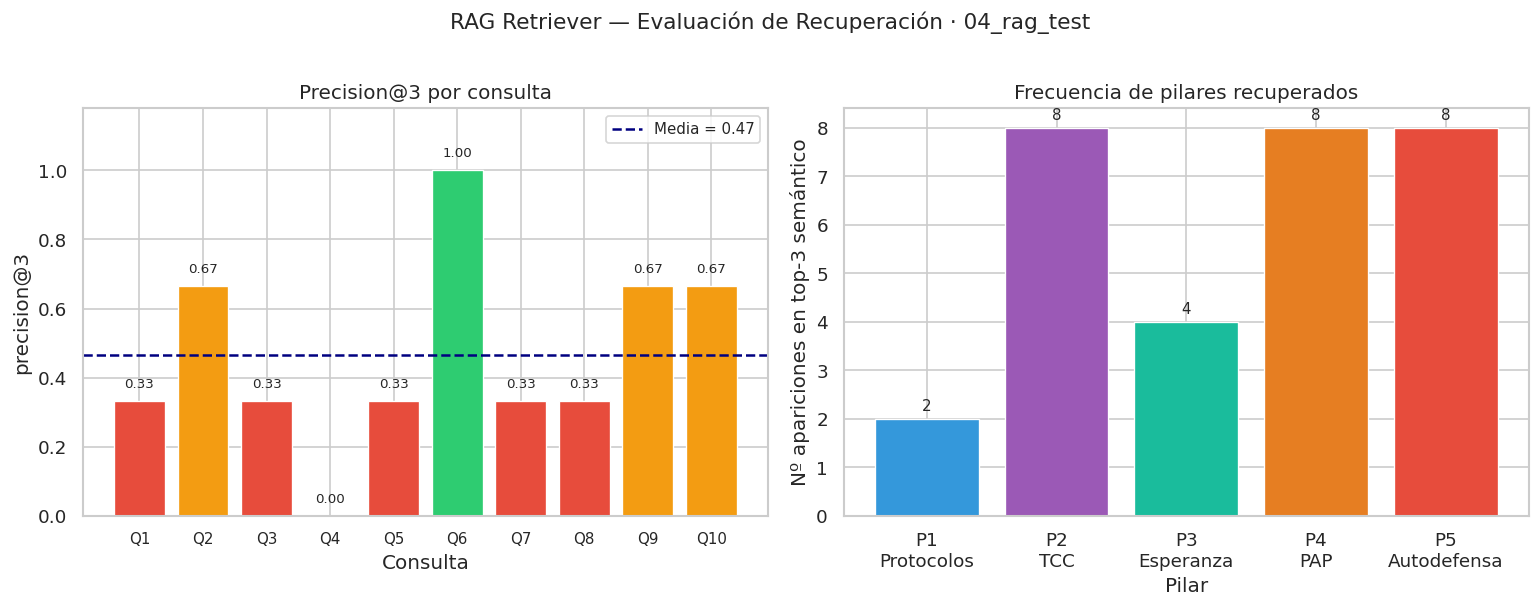

In [6]:
EVAL_DIR = PROJECT_ROOT / "eval"
EVAL_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)
fig.suptitle(
    "RAG Retriever — Evaluación de Recuperación · 04_rag_test",
    fontsize=13,
    y=1.01,
)

# ── Panel izquierdo: precision@3 por consulta ────────────────────────────────
ax1     = axes[0]
labels  = [r["tc"]["label"] for r in all_results]
p3_vals = [r["p_at_3"] for r in all_results]
bar_col = ["#2ecc71" if v >= 0.67 else "#f39c12" if v >= 0.34 else "#e74c3c"
           for v in p3_vals]

ax1.bar(labels, p3_vals, color=bar_col, edgecolor="white", linewidth=0.8)
ax1.axhline(
    global_p3,
    color="navy",
    linewidth=1.5,
    linestyle="--",
    label=f"Media = {global_p3:.2f}",
)
ax1.set_ylim(0, 1.18)
ax1.set_xlabel("Consulta")
ax1.set_ylabel("precision@3")
ax1.set_title("Precision@3 por consulta")
ax1.legend(fontsize=9)
ax1.tick_params(axis="x", labelsize=9)
for x, v in enumerate(p3_vals):
    ax1.text(x, v + 0.03, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

# ── Panel derecho: distribución de pilares recuperados ───────────────────────
ax2           = axes[1]
pillar_counts = Counter()
for res in all_results:
    for r in res["semantic"]:
        key = f"P{r.chunk.pillar}\n{PILLAR_NAMES[r.chunk.pillar]}"
        pillar_counts[key] += 1

pilar_labels = sorted(pillar_counts.keys())
pilar_vals   = [pillar_counts[k] for k in pilar_labels]
panel_colors = ["#3498db", "#9b59b6", "#1abc9c", "#e67e22", "#e74c3c"]

ax2.bar(
    pilar_labels,
    pilar_vals,
    color=panel_colors[: len(pilar_labels)],
    edgecolor="white",
    linewidth=0.8,
)
ax2.set_xlabel("Pilar")
ax2.set_ylabel("Nº apariciones en top-3 semántico")
ax2.set_title("Frecuencia de pilares recuperados")
for x, v in enumerate(pilar_vals):
    ax2.text(x, v + 0.1, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()

save_path = EVAL_DIR / "rag_test_precision.png"
fig.savefig(save_path, dpi=120, bbox_inches="tight")
print(f"Figura guardada en: {save_path}")
plt.show()

## Análisis de resultados

**Global precision@3 = 0.47 · hit@any = 0.90**

### Consultas con precision@3 = 1.0
- **Q6** (bloqueo Instagram): recuperación perfecta — P5 domina completamente el espacio semántico de "bloquear en red social".

### Consultas con precision@3 ≥ 0.67
- **Q2** (fotos sin permiso): 2/3 correctos (P5, P5); P2 se cuela como tercer resultado.
- **Q9** (ideación suicida): 2/3 correctos (P4, P4) + forced P4_007. Buen comportamiento en el caso más crítico.
- **Q10** (vergüenza): 2/3 correctos (P2, P2); P4 se introduce como tercer resultado.

### Consultas con precision@3 < 0.34
- **Q1** (miedo + amenazas): 1/3 correctos (P1); el único válido que cae en segunda posición. Al detectar la palabra amenaza detecta el chunk de P4 de amenaza física. El chunk de P3 no tiene sentido, ya que no ha expuesto el motivo por el que le amenzan en internet.
- **Q3** (llorar): recupera P4 (crisis) en lugar de P2 (TCC). El vocabulario emocional de tristeza intensa activa el pilar de crisis.
- **Q4** (todo el mundo me odia, p@3=0.00): recupera P3/P5/P5. La distorsión cognitiva "todo/nada" no consigue obtener el léxico explícito de reestructuración cognitiva en P2. Sin embargo, el chunk de P3 sobre fuentes de esperanza y P5 sobre las medidas para protegerse en Whatsapp se consideran salidas correctas para este caso.
- **Q5** (denunciar): 1/3 correcto (P1); "denunciar" arrastra hacia P5 (autodefensa digital) y "acosar" o "amenazar" arrastra hacia P4 (amenaza física).
- **Q7** (no sirvo para nada): recupera P2/P3/P2; solo 1 hit en P3. Baja autoestima se solapa con TCC que se puede considerar correcto.
- **Q8** (amenaza física): recupera en primera posición el chunk de P4 que deseamos sobre la amenaza física.